# Segmentation and Recommendation Model – Customer Churn



## 1. Dataset Overview



In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("customer_churn_sample.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 2. Data Inspection



In [24]:
print("Number of customers:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(list(df.columns))

Number of customers: 15
Number of columns: 11

Column names:
['CustomerID', 'Gender', 'Age', 'TenureMonths', 'SubscriptionType', 'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets', 'PaymentMethod', 'Churn']


In [25]:
print("Data types:\n")
print(df.dtypes)

Data types:

CustomerID           object
Gender               object
Age                   int64
TenureMonths          int64
SubscriptionType     object
MonthlyCharges      float64
TotalCharges        float64
ContractType         object
SupportTickets        int64
PaymentMethod        object
Churn                object
dtype: object


In [26]:
df.head()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes


In [27]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,15,15,CUST-1001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,15,2,Female,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,15.0,NaN,NaN,NaN,39.066667,11.392144,23.0,30.0,38.0,47.0,60.0
TenureMonths,15.0,NaN,NaN,NaN,18.8,14.333776,2.0,7.0,15.0,27.0,48.0
SubscriptionType,15,3,Basic,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyCharges,15.0,NaN,NaN,NaN,84.656667,42.739521,49.99,49.99,79.99,114.99,149.99
TotalCharges,15.0,NaN,NaN,NaN,2088.478667,2407.365767,99.98,449.91,1099.78,3209.73,7199.52
ContractType,15,3,Month-to-Month,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SupportTickets,15.0,NaN,NaN,NaN,2.533333,1.9223,0.0,1.0,2.0,4.0,6.0
PaymentMethod,15,4,Credit Card,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
CustomerID          0
Gender              0
Age                 0
TenureMonths        0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
ContractType        0
SupportTickets      0
PaymentMethod       0
Churn               0
dtype: int64


## 3. Customer Segmentation Method



In [29]:
def assign_segment(contract):
    if contract == "Month-to-Month":
        return "New / Month-to-Month Customers"
    elif contract == "One Year":
        return "Established Annual Customers"
    elif contract == "Two Year":
        return "Loyal Long-Term Customers"
    else:
        return "Unclassified"

df['Segment'] = df['ContractType'].apply(assign_segment)
df[['CustomerID', 'ContractType', 'Segment']]

,CustomerID,ContractType,Segment
0,CUST-1001,Month-to-Month,New / Month-to-Month Customers
1,CUST-1002,One Year,Established Annual Customers
2,CUST-1003,Month-to-Month,New / Month-to-Month Customers
3,CUST-1004,Two Year,Loyal Long-Term Customers
4,CUST-1005,Month-to-Month,New / Month-to-Month Customers
5,CUST-1006,One Year,Established Annual Customers
6,CUST-1007,Month-to-Month,New / Month-to-Month Customers
7,CUST-1008,Two Year,Loyal Long-Term Customers
8,CUST-1009,One Year,Established Annual Customers
9,CUST-1010,Month-to-Month,New / Month-to-Month Customers


In [30]:
segment_summary = df.groupby('Segment').agg(
    Number_of_Customers=('CustomerID', 'count'),
    Avg_Tenure_Months=('TenureMonths', 'mean'),
    Avg_Monthly_Charge=('MonthlyCharges', 'mean'),
    Avg_Support_Tickets=('SupportTickets', 'mean'),
).reset_index()

segment_summary['Pct_of_Customers'] = (segment_summary['Number_of_Customers'] / len(df) * 100).round(1)
segment_summary['Observed_Churn_Rate_%'] = (
    df.groupby('Segment')['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).values
).round(1)

segment_summary = segment_summary[['Segment', 'Number_of_Customers', 'Pct_of_Customers',
                                    'Avg_Tenure_Months', 'Avg_Monthly_Charge',
                                    'Avg_Support_Tickets', 'Observed_Churn_Rate_%']]
segment_summary

,Segment,Number_of_Customers,Pct_of_Customers,Avg_Tenure_Months,Avg_Monthly_Charge,Avg_Support_Tickets,Observed_Churn_Rate_%
0,Established Annual Customers,4,26.7,19.75,64.990000,1.500000,0.0
1,Loyal Long-Term Customers,4,26.7,38.50,149.990000,0.500000,0.0
2,New / Month-to-Month Customers,7,46.7,7.00,58.561429,4.285714,100.0


## 4. Rule-Based Churn-Risk Scoring Method



In [31]:
def tenure_points(tenure):
    if tenure <= 6:
        return 30, "Short tenure (<=6 months)"
    elif tenure <= 18:
        return 15, "Moderate tenure (7-18 months)"
    else:
        return 0, "Long tenure (>18 months)"

def ticket_points(tickets):
    if tickets >= 4:
        return 25, "High support-ticket volume (>=4 tickets)"
    elif tickets >= 2:
        return 10, "Moderate support-ticket volume (2-3 tickets)"
    else:
        return 0, "Low support-ticket volume (<=1 ticket)"

def contract_points(contract):
    if contract == "Month-to-Month":
        return 30, "Month-to-Month contract (lowest commitment)"
    elif contract == "One Year":
        return 10, "One Year contract (medium commitment)"
    else:
        return 0, "Two Year contract (highest commitment)"

tenure_results = df['TenureMonths'].apply(tenure_points)
ticket_results = df['SupportTickets'].apply(ticket_points)
contract_results = df['ContractType'].apply(contract_points)

df['TenurePoints']   = tenure_results.apply(lambda x: x[0])
df['TenureReason']   = tenure_results.apply(lambda x: x[1])
df['TicketPoints']   = ticket_results.apply(lambda x: x[0])
df['TicketReason']   = ticket_results.apply(lambda x: x[1])
df['ContractPoints'] = contract_results.apply(lambda x: x[0])
df['ContractReason'] = contract_results.apply(lambda x: x[1])

df['TotalRiskScore'] = df['TenurePoints'] + df['TicketPoints'] + df['ContractPoints']

df[['CustomerID', 'TenurePoints', 'TicketPoints', 'ContractPoints', 'TotalRiskScore']]

,CustomerID,TenurePoints,TicketPoints,ContractPoints,TotalRiskScore
0,CUST-1001,15,10,30,55
1,CUST-1002,0,0,10,10
2,CUST-1003,30,25,30,85
3,CUST-1004,0,0,0,0
4,CUST-1005,15,25,30,70
5,CUST-1006,15,10,10,35
6,CUST-1007,30,25,30,85
7,CUST-1008,0,0,0,0
8,CUST-1009,15,10,10,35
9,CUST-1010,30,25,30,85


## 5. Risk Level Classification



In [32]:
def risk_level(score):
    if score <= 25:
        return "Low Risk"
    elif score <= 55:
        return "Medium Risk"
    else:
        return "High Risk"

df['RiskLevel'] = df['TotalRiskScore'].apply(risk_level)

df[['CustomerID', 'TotalRiskScore', 'RiskLevel', 'Churn']]

,CustomerID,TotalRiskScore,RiskLevel,Churn
0,CUST-1001,55,Medium Risk,Yes
1,CUST-1002,10,Low Risk,No
2,CUST-1003,85,High Risk,Yes
3,CUST-1004,0,Low Risk,No
4,CUST-1005,70,High Risk,Yes
5,CUST-1006,35,Medium Risk,No
6,CUST-1007,85,High Risk,Yes
7,CUST-1008,0,Low Risk,No
8,CUST-1009,35,Medium Risk,No
9,CUST-1010,85,High Risk,Yes


In [33]:
final_table = df[['CustomerID', 'Gender', 'Age', 'TenureMonths', 'SubscriptionType',
                   'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets',
                   'PaymentMethod', 'Segment',
                   'TenurePoints', 'TicketPoints', 'ContractPoints',
                   'TotalRiskScore', 'RiskLevel', 'Churn']].copy()

final_table.to_csv("customer_segment_table.csv", index=False)

risk_scores_table = df[['CustomerID', 'Segment', 'TenurePoints', 'TenureReason',
                         'TicketPoints', 'TicketReason', 'ContractPoints', 'ContractReason',
                         'TotalRiskScore', 'RiskLevel', 'Churn']].copy()
risk_scores_table.to_csv("churn_risk_scores.csv", index=False)

print("Saved: customer_segment_table.csv")
print("Saved: churn_risk_scores.csv")
final_table.head()

Saved: customer_segment_table.csv
Saved: churn_risk_scores.csv


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Segment,TenurePoints,TicketPoints,ContractPoints,TotalRiskScore,RiskLevel,Churn
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,New / Month-to-Month Customers,15,10,30,55,Medium Risk,Yes
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,Established Annual Customers,0,0,10,10,Low Risk,No
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,New / Month-to-Month Customers,30,25,30,85,High Risk,Yes
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,Loyal Long-Term Customers,0,0,0,0,Low Risk,No
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,New / Month-to-Month Customers,15,25,30,70,High Risk,Yes


## 6. Score Explanation (Per-Customer)



In [34]:
def explain_customer(row):
    print(f"Customer: {row['CustomerID']}")
    print(f"Risk Score: {row['TotalRiskScore']}")
    print(f"Risk Level: {row['RiskLevel']}")
    print("Reasons:")
    print(f"  - {row['TenureReason']}: +{row['TenurePoints']}")
    print(f"  - {row['TicketReason']}: +{row['TicketPoints']}")
    print(f"  - {row['ContractReason']}: +{row['ContractPoints']}")
    print(f"Actual churn status: {row['Churn']}")
    print("-" * 50)

# Example: explain the highest-risk and lowest-risk customers
highest = df.loc[df['TotalRiskScore'].idxmax()]
lowest = df.loc[df['TotalRiskScore'].idxmin()]

explain_customer(highest)
explain_customer(lowest)

Customer: CUST-1003
Risk Score: 85
Risk Level: High Risk
Reasons:
  - Short tenure (<=6 months): +30
  - High support-ticket volume (>=4 tickets): +25
  - Month-to-Month contract (lowest commitment): +30
Actual churn status: Yes
--------------------------------------------------
Customer: CUST-1004
Risk Score: 0
Risk Level: Low Risk
Reasons:
  - Long tenure (>18 months): +0
  - Low support-ticket volume (<=1 ticket): +0
  - Two Year contract (highest commitment): +0
Actual churn status: No
--------------------------------------------------


In [35]:
# Full explanation for every customer in the dataset
for _, row in df.iterrows():
    explain_customer(row)

Customer: CUST-1001
Risk Score: 55
Risk Level: Medium Risk
Reasons:
  - Moderate tenure (7-18 months): +15
  - Moderate support-ticket volume (2-3 tickets): +10
  - Month-to-Month contract (lowest commitment): +30
Actual churn status: Yes
--------------------------------------------------
Customer: CUST-1002
Risk Score: 10
Risk Level: Low Risk
Reasons:
  - Long tenure (>18 months): +0
  - Low support-ticket volume (<=1 ticket): +0
  - One Year contract (medium commitment): +10
Actual churn status: No
--------------------------------------------------
Customer: CUST-1003
Risk Score: 85
Risk Level: High Risk
Reasons:
  - Short tenure (<=6 months): +30
  - High support-ticket volume (>=4 tickets): +25
  - Month-to-Month contract (lowest commitment): +30
Actual churn status: Yes
--------------------------------------------------
Customer: CUST-1004
Risk Score: 0
Risk Level: Low Risk
Reasons:
  - Long tenure (>18 months): +0
  - Low support-ticket volume (<=1 ticket): +0
  - Two Year contra

## 7. Edge-Case Validation



In [36]:
print("VALIDATION CHECKS")
print("=" * 50)

# 1. No negative scores
print("1. Minimum score in dataset:", df['TotalRiskScore'].min(), "-> No negative scores:", (df['TotalRiskScore'] >= 0).all())

# 2. Scores stay within defined range (0-85)
print("2. Maximum score in dataset:", df['TotalRiskScore'].max(), "-> Within 0-85 range:", df['TotalRiskScore'].between(0, 85).all())

# 3. Every customer has a risk level assigned
print("3. Customers with a Risk Level assigned:", df['RiskLevel'].notnull().sum(), "of", len(df))

# 4. No customer left unclassified
valid_levels = {"Low Risk", "Medium Risk", "High Risk"}
print("4. All risk levels are valid categories:", df['RiskLevel'].isin(valid_levels).all())

# 5. Missing values check
print("5. Missing values in scoring inputs (TenureMonths, SupportTickets, ContractType):")
print(df[['TenureMonths', 'SupportTickets', 'ContractType']].isnull().sum().to_dict())

# 6. Customer with the fewest observed risk indicators (all rules = 0 points)
zero_risk = df[(df['TenurePoints']==0) & (df['TicketPoints']==0) & (df['ContractPoints']==0)]
print("\n6. Customers with NO risk indicators triggered (all rules = 0):")
print(zero_risk[['CustomerID','TotalRiskScore','RiskLevel','Churn']].to_string(index=False) if len(zero_risk) else "  None in this dataset")

# 7. Customer(s) with maximum observed score (all rules triggered at highest tier)
max_risk = df[df['TotalRiskScore'] == df['TotalRiskScore'].max()]
print("\n7. Customer(s) at the MAXIMUM observed score:")
print(max_risk[['CustomerID','TotalRiskScore','RiskLevel','Churn']].to_string(index=False))

# 8. Customer(s) with the minimum observed score
min_risk = df[df['TotalRiskScore'] == df['TotalRiskScore'].min()]
print("\n8. Customer(s) at the MINIMUM observed score:")
print(min_risk[['CustomerID','TotalRiskScore','RiskLevel','Churn']].to_string(index=False))

VALIDATION CHECKS
1. Minimum score in dataset: 0 -> No negative scores: True
2. Maximum score in dataset: 85 -> Within 0-85 range: True
3. Customers with a Risk Level assigned: 15 of 15
4. All risk levels are valid categories: True
5. Missing values in scoring inputs (TenureMonths, SupportTickets, ContractType):
{'TenureMonths': 0, 'SupportTickets': 0, 'ContractType': 0}

6. Customers with NO risk indicators triggered (all rules = 0):
CustomerID  TotalRiskScore RiskLevel Churn
 CUST-1004               0  Low Risk    No
 CUST-1008               0  Low Risk    No
 CUST-1011               0  Low Risk    No
 CUST-1015               0  Low Risk    No

7. Customer(s) at the MAXIMUM observed score:
CustomerID  TotalRiskScore RiskLevel Churn
 CUST-1003              85 High Risk   Yes
 CUST-1007              85 High Risk   Yes
 CUST-1010              85 High Risk   Yes
 CUST-1014              85 High Risk   Yes

8. Customer(s) at the MINIMUM observed score:
CustomerID  TotalRiskScore RiskLevel 

## 8. Segment-Level Analysis



In [37]:
segment_analysis = df.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Churn_Count=('Churn', lambda s: (s == 'Yes').sum()),
    Avg_Tenure=('TenureMonths', 'mean'),
    Avg_Monthly_Charges=('MonthlyCharges', 'mean'),
    Avg_Support_Tickets=('SupportTickets', 'mean'),
    Avg_Risk_Score=('TotalRiskScore', 'mean'),
    High_Risk_Count=('RiskLevel', lambda s: (s == 'High Risk').sum()),
).reset_index()

segment_analysis['Pct_of_Customers'] = (segment_analysis['Customer_Count'] / len(df) * 100).round(1)
segment_analysis['Observed_Churn_Rate_%'] = (segment_analysis['Churn_Count'] / segment_analysis['Customer_Count'] * 100).round(1)
segment_analysis['Total_Monthly_Revenue'] = df.groupby('Segment')['MonthlyCharges'].sum().values

segment_analysis = segment_analysis[['Segment', 'Customer_Count', 'Pct_of_Customers', 'Churn_Count',
                                      'Observed_Churn_Rate_%', 'Avg_Tenure', 'Avg_Monthly_Charges',
                                      'Avg_Support_Tickets', 'Avg_Risk_Score', 'High_Risk_Count',
                                      'Total_Monthly_Revenue']]
segment_analysis

,Segment,Customer_Count,Pct_of_Customers,Churn_Count,Observed_Churn_Rate_%,Avg_Tenure,Avg_Monthly_Charges,Avg_Support_Tickets,Avg_Risk_Score,High_Risk_Count,Total_Monthly_Revenue
0,Established Annual Customers,4,26.7,0,0.0,19.75,64.990000,1.500000,22.500000,0,259.96
1,Loyal Long-Term Customers,4,26.7,0,0.0,38.50,149.990000,0.500000,0.000000,0,599.96
2,New / Month-to-Month Customers,7,46.7,7,100.0,7.00,58.561429,4.285714,74.285714,5,409.93


## 9. Visualizations

/tmp/ipykernel_3488/3312746532.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Segment', order=df['Segment'].value_counts().index, palette='Blues_d', ax=ax)


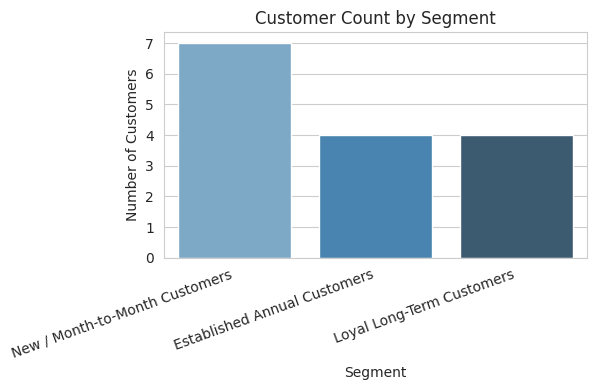

In [38]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x='Segment', order=df['Segment'].value_counts().index, palette='Blues_d', ax=ax)
ax.set_title('Customer Count by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart_1_segment_count.png')
plt.show()

/tmp/ipykernel_3488/3947284498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RiskLevel', order=order, palette='Oranges', ax=ax)


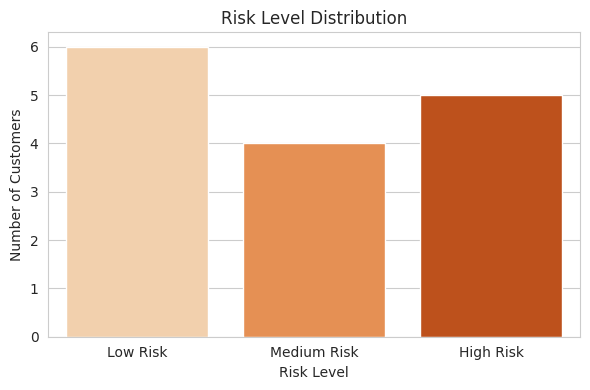

In [39]:
fig, ax = plt.subplots(figsize=(6,4))
order = ['Low Risk', 'Medium Risk', 'High Risk']
sns.countplot(data=df, x='RiskLevel', order=order, palette='Oranges', ax=ax)
ax.set_title('Risk Level Distribution')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('chart_2_risk_distribution.png')
plt.show()

/tmp/ipykernel_3488/2311762234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_analysis, x='Segment', y='Avg_Risk_Score', palette='Reds_d', ax=ax)


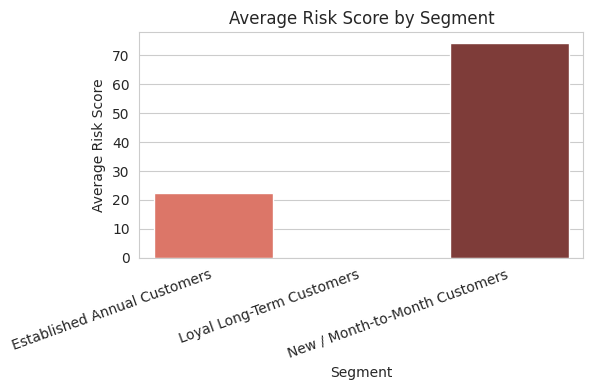

In [40]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=segment_analysis, x='Segment', y='Avg_Risk_Score', palette='Reds_d', ax=ax)
ax.set_title('Average Risk Score by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Average Risk Score')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart_3_avg_risk_by_segment.png')
plt.show()

/tmp/ipykernel_3488/3748658059.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_analysis, x='Segment', y='Observed_Churn_Rate_%', palette='Purples_d', ax=ax)


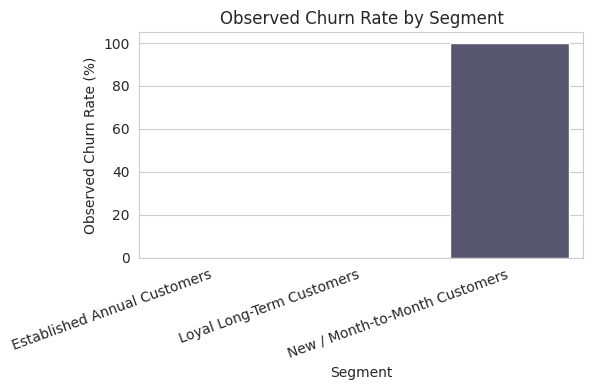

In [41]:
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=segment_analysis, x='Segment', y='Observed_Churn_Rate_%', palette='Purples_d', ax=ax)
ax.set_title('Observed Churn Rate by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Observed Churn Rate (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('chart_4_churn_rate_by_segment.png')
plt.show()

/tmp/ipykernel_3488/2775118220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y='SupportTickets', order=order, palette='Greens', ax=ax)


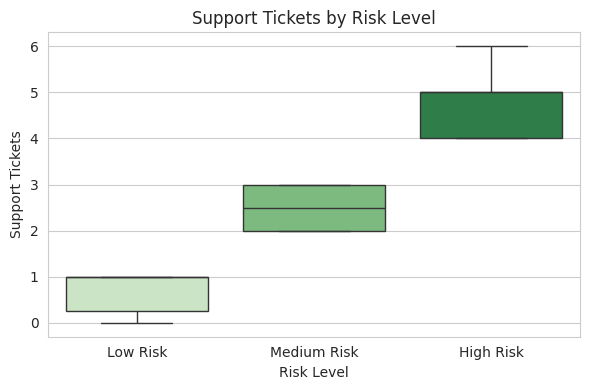

In [42]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='RiskLevel', y='SupportTickets', order=order, palette='Greens', ax=ax)
ax.set_title('Support Tickets by Risk Level')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Support Tickets')
plt.tight_layout()
plt.savefig('chart_5_tickets_by_risklevel.png')
plt.show()

/tmp/ipykernel_3488/2748931097.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiskLevel', y='TenureMonths', order=order, palette='Blues', ax=ax)


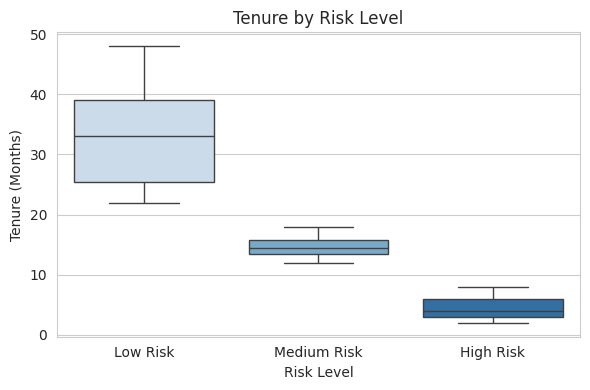

In [43]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='RiskLevel', y='TenureMonths', order=order, palette='Blues', ax=ax)
ax.set_title('Tenure by Risk Level')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Tenure (Months)')
plt.tight_layout()
plt.savefig('chart_6_tenure_by_risklevel.png')
plt.show()